# Differential gene expression
https://pertpy.readthedocs.io/en/stable/tutorials/notebooks/differential_gene_expression.html

In this tutorial, we explore DGE across distinct cell populations and perturbations. Pertpy has an API to several DGE models

* Simple statistical tests
* Pseudo bulks + GLMs (like PyDESeq)
* Generic linear models - for when the response variable does not look like a count (log-normalized expression, or a continuous score)

In [1]:
import decoupler as dc
import pertpy as pt
import scanpy as sc
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

Here we'll use the Zhang dataset, which contains scRNA-seq data from 22 patients with advanced triple negative breast cancer (TNBC), treated with paclitaxel alone and in combination with anti-PD-L1 therapy atezolizumab.

This data contains tumor and blood samples pre-treatment, post-treatment, and during disease progression.

In [2]:
adata = pt.dt.zhang_2021() # this is a LOT of data, feel free to delete datafile after finishing the analysis

Because this is such a big dataset, for now let's work with just the tissue samples

In [3]:
adata = adata[adata.obs['Origin'] == 't', :].copy()

In [4]:
adata

AnnData object with n_obs × n_vars = 167244 × 27085
    obs: 'Sample', 'Patient', 'Origin', 'Tissue', 'Efficacy', 'Group', 'Treatment', 'Number of counts', 'Number of genes', 'Major celltype', 'Cluster'
    layers: None (.X)

Let's do some initial QC. One patient has extremely few cells sequenced. There are 2 samples with low cell count - these won't be removed, but just keep them in mind.

In [5]:
print(adata.obs['Patient'].value_counts()) # patient 10 has very few sequenced cells. let's remove them

adata = adata[~adata.obs['Patient'].isin(['P010'])]
print('')

print(adata.obs['Sample'].value_counts()) # patient 10 has very few sequenced cells. let's remove them

Patient
P019    37150
P013    22526
P012    14570
P025    14505
P002    10909
P022    10614
P023    10123
P005     8175
P018     7936
P020     7240
P007     7237
P003     4349
P016     4009
P017     4006
P004     3887
P010        8
Name: count, dtype: int64

Sample
Pre_P019_t     27656
Prog_P013_t    10153
Post_P013_t     9975
Post_P019_t     9494
Post_P025_t     8072
Pre_P022_t      7689
Pre_P012_t      7682
Post_P012_t     6888
Pre_P020_t      6863
Post_P023_t     6813
Pre_P025_t      6433
Post_P018_t     5847
Pre_P002_t      5483
Post_P002_t     5426
Pre_P007_t      4999
Pre_P005_t      4432
Post_P003_t     4349
Pre_P004_t      3887
Pre_P016_t      3862
Post_P005_t     3743
Pre_P023_t      3310
Post_P022_t     2925
Pre_P017_t      2428
Pre_P013_t      2398
Prog_P007_t     2238
Pre_P018_t      2089
Post_P017_t     1578
Post_P020_t      377
Post_P016_t      147
Name: count, dtype: int64


## Exploring the data's variables
Here are the different tissue types

In [6]:
adata.obs['Tissue'].value_counts()

Tissue
lymph_node    60725
breast        50418
liver         30701
chest_wall    23154
brain          2238
Name: count, dtype: int64

Plus the different treatments each patient may have received

In [7]:
adata.obs['Treatment'].value_counts()

Treatment
Anti-PD-L1+Chemo    89943
Chemo               77293
Name: count, dtype: int64

And the efficacy of each of the treatments. PR = partial response, SD = stable disease, PD = progressive disease

In [8]:
adata.obs['Efficacy'].value_counts()

Efficacy
PR    99337
SD    63550
PD     4349
Name: count, dtype: int64

Here's when the samples were collected (pre, post, or during treatment)

In [9]:
adata.obs['Group'].value_counts()

Group
Pre-treatment     89211
Post-treatment    65634
Progression       12391
Name: count, dtype: int64

Each cell was annotated at two different resolutions: 'Major celltype' and 'Cluster'. The 'Cluster' category contains more specific annotations, and also contains a 'Mix' label, whose cells we will remove just like in the original publication.

For the rest of the analysis, we'll work at the more specific 'Cluster' level. 'Major celltype' is not specific enough.

In [10]:
adata = adata[~adata.obs['Cluster'].isin(['Mix'])]

In [11]:
adata.layers['counts'] = adata.X.copy()

C:\Users\CT\AppData\Local\Temp\ipykernel_25556\1155977868.py:1: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  adata.layers['counts'] = adata.X.copy()


In [12]:
adata

AnnData object with n_obs × n_vars = 163090 × 27085
    obs: 'Sample', 'Patient', 'Origin', 'Tissue', 'Efficacy', 'Group', 'Treatment', 'Number of counts', 'Number of genes', 'Major celltype', 'Cluster'
    layers: None (.X), 'counts'

## Pseudobulking
Pseudobulking within each group and sample of interest before any DE analysis is a best practice. This approach lets us leverage statistics developed for bulk RNA-seq data, which helps minimize false positives when analysizing single cell data.

For each patient, we'll create a single pseudobulk sample per cell type by summing up gene counts.

In [13]:
pdata = dc.pp.pseudobulk(adata, sample_col='Patient', groups_col='Cluster', layer='counts', mode='sum')
dc.pp.filter_samples(pdata, inplace=True)

In [14]:
pdata

AnnData object with n_obs × n_vars = 457 × 27085
    obs: 'Patient', 'Cluster', 'Origin', 'Efficacy', 'Treatment', 'Major celltype', 'psbulk_cells', 'psbulk_counts'
    layers: 'psbulk_props', None (.X)

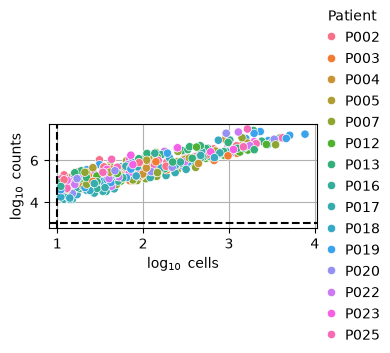

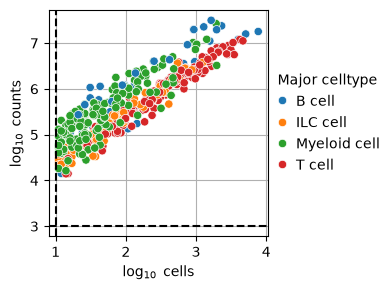

In [15]:
dc.pl.filter_samples(pdata, groupby=['Patient'])
dc.pl.filter_samples(pdata, groupby=['Major celltype'])

## Exploring variability
Now that we have generated psuedobulk profiles of each cell type in each patient, let's explore the variation. First, some simple preprocessing of the pseudobulk counts and a PCA.

In [16]:
pdata.layers['counts'] = pdata.X.copy()

In [17]:
sc.pp.normalize_total(pdata, target_sum=1e4)
sc.pp.log1p(pdata)
sc.pp.scale(pdata, max_value=10)

sc.pp.pca(pdata)

In [18]:
# return raw counts to X, and have the counts in 'layers' be the preprocessed counts
dc.pp.swap_layer(pdata, 'counts', inplace=True)

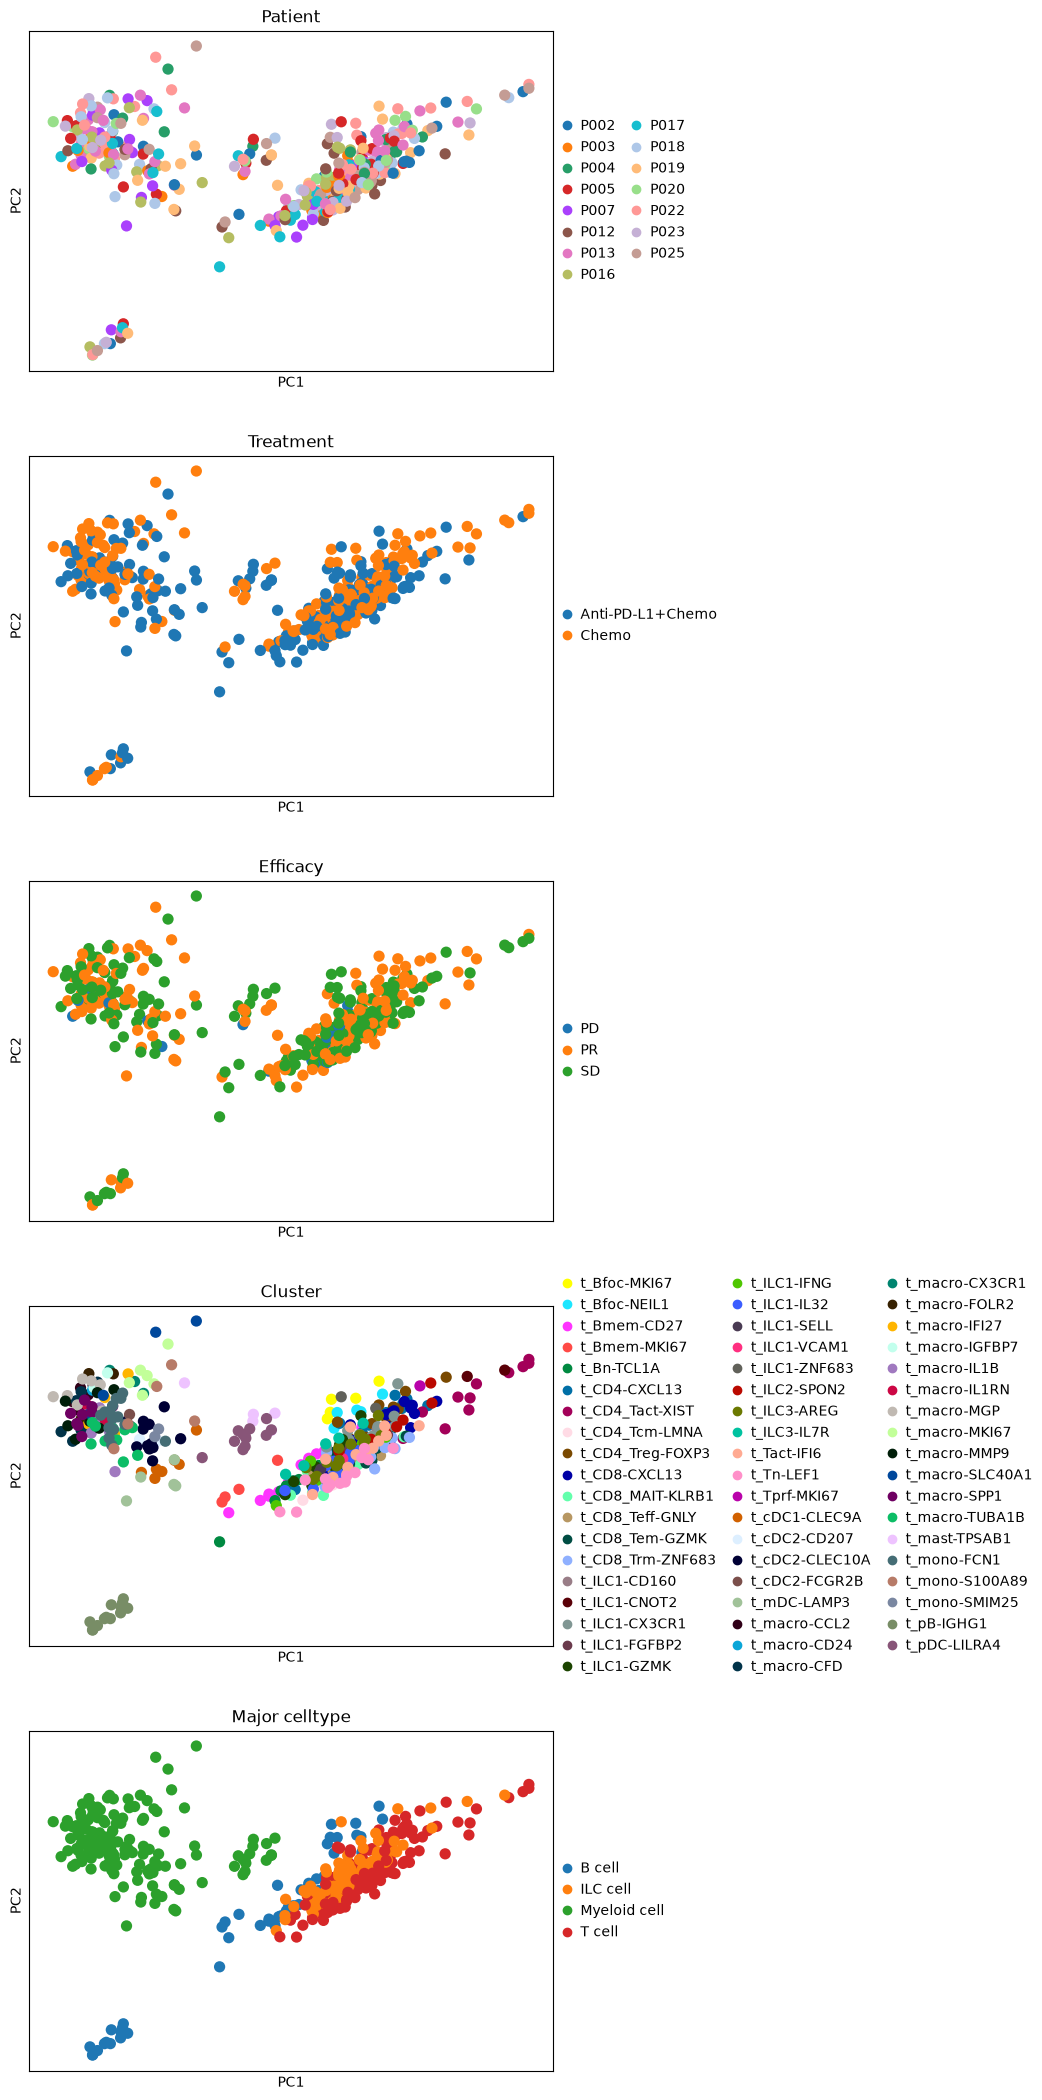

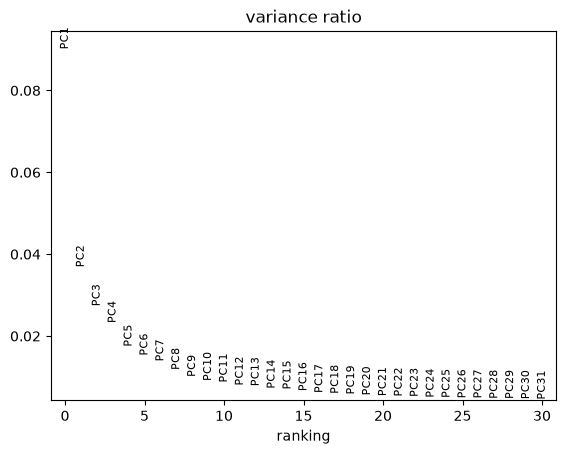

In [19]:
sc.pl.pca(pdata, color=['Patient', 'Treatment', 'Efficacy', 'Cluster', 'Major celltype'], ncols=1)
sc.pl.pca_variance_ratio(pdata)

It seems like PC1-4 (maybe 5) explain the vast majority of variability in our pseudobulk counts. In particular, PC1-2 seem pretty associated with major celltype.

We can specifically do an ANOVA on each PC to see their association with the sample metadeta.

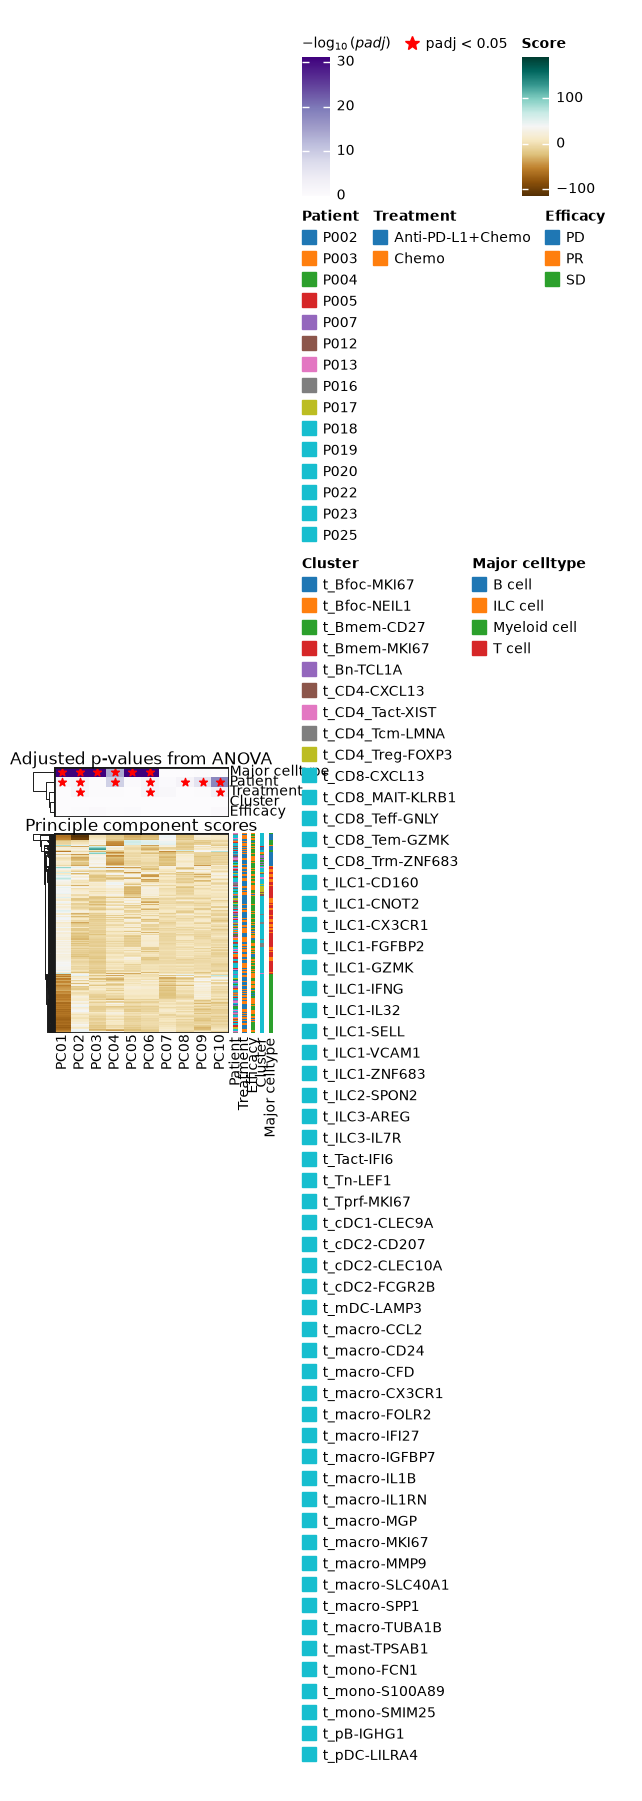

In [20]:
#pdata_subset = pdata.copy()
#pdata_subset.obs = pdata.obs[["Patient", "Treatment", "Efficacy", "Cluster", "Major celltype"]]

# this function ranks features in adata.obsm by the significance of their association with metadata in adata.obs
# which is why we subset the obs columns first
dc.tl.rankby_obsm(
    pdata,
    key="X_pca",
    uns_key="pca_anova",
    obs_keys = ["Patient", "Treatment", "Efficacy", "Cluster", "Major celltype"]
)


dc.pl.obsm(
    pdata,
    key="pca_anova",
    names=["Patient", "Treatment", "Efficacy", "Cluster", "Major celltype"],
    titles=["Principle component scores", "Adjusted p-values from ANOVA"],
    cmap_obs={},
)


## Differential expression with PyDESeq2

In [21]:
ds = pt.tl.PyDESeq2(adata=pdata, design='~Efficacy + Treatment')

Notably, we only model efficacy and treatment as additive - there is no interaction term between efficacy and treatment.

In [22]:
ds.fit()

Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 1.10 seconds.

Fitting dispersions...
... done in 10.80 seconds.

Fitting dispersion trend curve...
... done in 1.21 seconds.

Fitting MAP dispersions...
... done in 10.24 seconds.

Fitting LFCs...
... done in 13.52 seconds.

Calculating cook's distance...
... done in 1.06 seconds.

Replacing 729 outlier genes.

Fitting dispersions...
... done in 0.41 seconds.

Fitting MAP dispersions...
... done in 0.43 seconds.

Fitting LFCs...
... done in 0.70 seconds.



In [23]:
results_df = ds.test_contrasts(ds.contrast(column='Treatment', baseline='Chemo', group_to_compare='Anti-PD-L1+Chemo'))

Running Wald tests...
... done in 2.38 seconds.



Log2 fold change & Wald test p-value, contrast vector: [ 0.  0.  0. -1.]
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
AL627309.1   0.027626        0.627588  0.428325  1.465213  0.142863       NaN
AL669831.5   0.448998        0.069260  0.199902  0.346473  0.728988  0.853654
FAM87B       0.018980        0.526398  0.594508  0.885435  0.375922       NaN
LINC00115    1.599386       -0.190839  0.119325 -1.599319  0.109750  0.278629
NOC2L       12.462982       -0.086244  0.059517 -1.449061  0.147321  0.338360
...               ...             ...       ...       ...       ...       ...
AP001189.4   0.000000             NaN       NaN       NaN       NaN       NaN
AC011595.1   0.000000             NaN       NaN       NaN       NaN       NaN
TRDJ3        0.000000             NaN       NaN       NaN       NaN       NaN
GOLGA6L1     0.000000             NaN       NaN       NaN       NaN       NaN
AC008569.1   0.000000             NaN       NaN       NaN       NaN  

NaNs encountered, dropping rows with NaNs


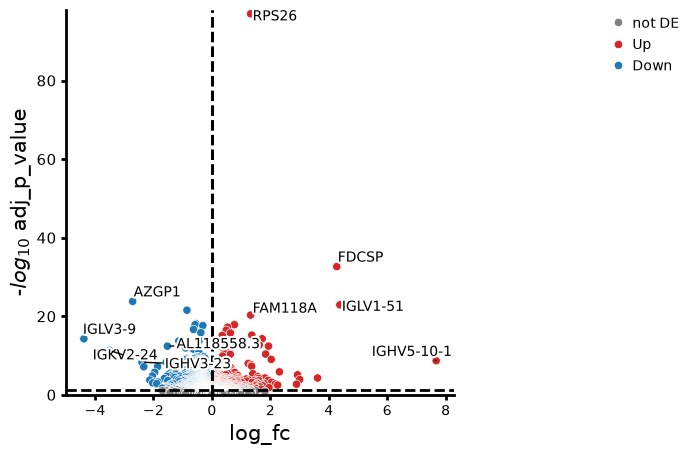

In [24]:
ds.plot_volcano(results_df, log2fc_threshold=0)

We can also plot fold changes of the top DE genes.

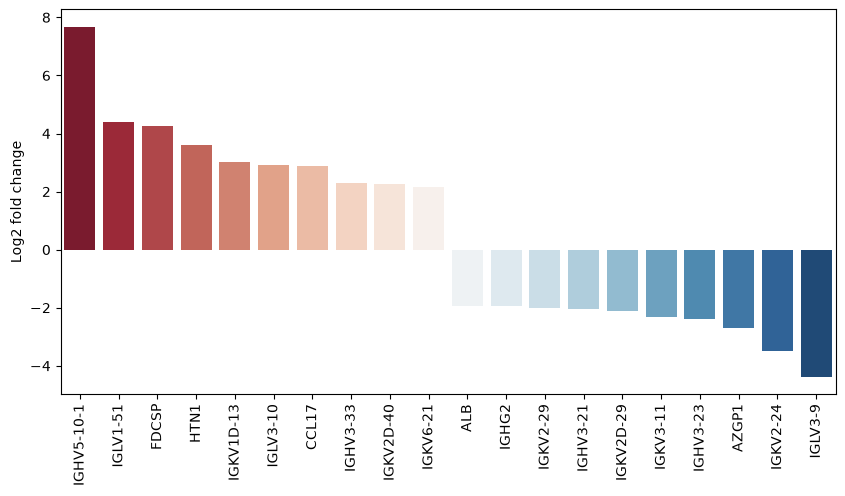

In [25]:
ds.plot_fold_change(results_df, n_top_vars=10)

Meanwhile, we can compare gene expression between the different efficacy groups (3 categories instead of 2):

In [26]:
results_df = ds.compare_groups(pdata, column='Efficacy', baseline='SD', groups_to_compare=['PR', 'PD'])

Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 1.12 seconds.

Fitting dispersions...
... done in 8.35 seconds.

Fitting dispersion trend curve...
... done in 1.09 seconds.

Fitting MAP dispersions...
... done in 10.06 seconds.

Fitting LFCs...
... done in 12.09 seconds.

Calculating cook's distance...
... done in 0.84 seconds.

Replacing 763 outlier genes.

Fitting dispersions...
... done in 0.35 seconds.

Fitting MAP dispersions...
... done in 0.40 seconds.

Fitting LFCs...
... done in 0.61 seconds.

Running Wald tests...
... done in 2.55 seconds.



Log2 fold change & Wald test p-value, contrast vector: [ 0.  1. -1.]
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
AL627309.1   0.027626       -0.465182  0.648117 -0.717744  0.472915       NaN
AL669831.5   0.448998       -0.385963  0.207275 -1.862081  0.062592  0.291232
FAM87B       0.018980       -0.281550  0.850533 -0.331028  0.740623       NaN
LINC00115    1.599386       -0.253359  0.122537 -2.067608  0.038677  0.226583
NOC2L       12.462982       -0.067935  0.058906 -1.153263  0.248802  0.576489
...               ...             ...       ...       ...       ...       ...
AP001189.4   0.000000             NaN       NaN       NaN       NaN       NaN
AC011595.1   0.000000             NaN       NaN       NaN       NaN       NaN
TRDJ3        0.000000             NaN       NaN       NaN       NaN       NaN
GOLGA6L1     0.000000             NaN       NaN       NaN       NaN       NaN
AC008569.1   0.000000             NaN       NaN       NaN       NaN      

Running Wald tests...
... done in 1.99 seconds.



Log2 fold change & Wald test p-value, contrast vector: [ 0.  0. -1.]
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
AL627309.1   0.027626        0.336717  1.425533  0.236204  0.813274       NaN
AL669831.5   0.448998       -0.205091  0.553762 -0.370359  0.711115       NaN
FAM87B       0.018980        0.544484  1.847610  0.294696  0.768226       NaN
LINC00115    1.599386       -0.224592  0.342216 -0.656288  0.511639  0.673681
NOC2L       12.462982       -0.241950  0.151776 -1.594129  0.110907  0.254633
...               ...             ...       ...       ...       ...       ...
AP001189.4   0.000000             NaN       NaN       NaN       NaN       NaN
AC011595.1   0.000000             NaN       NaN       NaN       NaN       NaN
TRDJ3        0.000000             NaN       NaN       NaN       NaN       NaN
GOLGA6L1     0.000000             NaN       NaN       NaN       NaN       NaN
AC008569.1   0.000000             NaN       NaN       NaN       NaN      

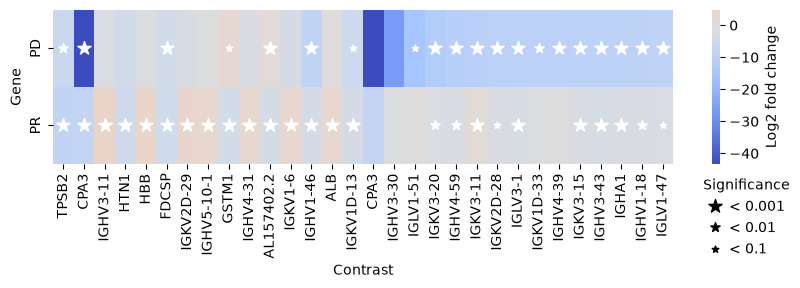

In [27]:
ds.plot_multicomparison_fc(results_df)

In [28]:
results_df

,variable,baseMean,log_fc,lfcSE,stat,p_value,adj_p_value,contrast,abs_log_fc,significance
0,AL157402.2,8.919279,-3.404111,0.206500,-16.484791,4.719220e-61,6.850892e-57,PR,3.404111,< 0.001
1,HBB,189.388797,4.362080,0.326806,13.347625,1.222859e-40,8.876123e-37,PR,4.362080,< 0.001
2,FDCSP,15.211450,-4.207208,0.379122,-11.097241,1.293763e-28,6.260518e-25,PR,4.207208,< 0.001
3,S100A1,5.076603,-2.650331,0.239924,-11.046531,2.278505e-28,8.269266e-25,PR,2.650331,< 0.001
4,TPSB2,21.233810,-8.368952,0.809621,-10.336875,4.799350e-25,1.393443e-21,PR,8.368952,< 0.001
...,...,...,...,...,...,...,...,...,...,...
27080,AP001189.4,0.000000,NaN,NaN,NaN,NaN,NaN,PD,NaN,n.s.
27081,AC011595.1,0.000000,NaN,NaN,NaN,NaN,NaN,PD,NaN,n.s.
27082,TRDJ3,0.000000,NaN,NaN,NaN,NaN,NaN,PD,NaN,n.s.
27083,GOLGA6L1,0.000000,NaN,NaN,NaN,NaN,NaN,PD,NaN,n.s.


# Introducing interaction between variables

So far, each analysis we've done has just assumed treatment and efficacy affects gene expression independently. We can break this assumption by introducing an interaction term between efficacy and treatment type in the original design formula.

In [29]:
# The 'PD' efficacy is seen only for one treatment condition. Let's remove it
pdata2 = pdata[pdata.obs['Efficacy'] != 'PD'].copy()

ds = pt.tl.PyDESeq2(adata=pdata2, design='~Efficacy + Treatment + Efficacy*Treatment')
ds.fit()

Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 1.00 seconds.

Fitting dispersions...
... done in 7.41 seconds.

Fitting dispersion trend curve...
... done in 1.07 seconds.

Fitting MAP dispersions...
... done in 8.40 seconds.

Fitting LFCs...
... done in 10.38 seconds.

Calculating cook's distance...
... done in 0.81 seconds.

Replacing 841 outlier genes.

Fitting dispersions...
... done in 0.37 seconds.

Fitting MAP dispersions...
... done in 0.34 seconds.

Fitting LFCs...
... done in 0.48 seconds.



Our output is gene expression, meanwhile our covariates are efficacy (PR vs SD) and treatment (chemo alone v/s chemo + Anti-PD-L1). Therefore, a question we can ask is which genes are associated with PR vs SD (responders v/s non-responders) when adding Anti-PD-L1 to standard chemotherapy.

To do this specifically in our analysis, we'll specify the contrast vector to PyDESeq2 using the `cond()` helper function, so we don't confuse which combinations of coefficients to use in our linear model correspond to the comparison we're trying to make.

See here for more details on how these contrast vectors work: https://formulaic-contrasts.readthedocs.io/en/latest/contrasts.html (Start at 'Comparison within a subset' for interaction terms)

In [30]:
interaction_contrast = (
    ( ds.cond(Treatment="Anti-PD-L1+Chemo", Efficacy="PR") - ds.cond(Treatment="Anti-PD-L1+Chemo", Efficacy="SD") ) # PR v/s SD within dual treatment) 
    - ( ds.cond(Treatment="Chemo", Efficacy="PR") - ds.cond(Treatment="Chemo", Efficacy="SD") )
)

In [31]:
interaction_contrast

Intercept                            0.0
Efficacy[T.SD]                       0.0
Treatment[T.Chemo]                   0.0
Efficacy[T.SD]:Treatment[T.Chemo]    1.0
Name: 0, dtype: float64

Another way to describe this contrast vector and what we are trying to determine is "the difference of the difference between responders and non-responders in drugA v/s drug B".

Now let's do the actual tests!

In [32]:
interaction_results_df = ds.test_contrasts(interaction_contrast)

Running Wald tests...
... done in 2.17 seconds.



Log2 fold change & Wald test p-value, contrast vector: [0. 0. 0. 1.]
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
AL627309.1   0.030299        0.441929  1.260079  0.350716  0.725802       NaN
AL669831.5   0.481510        0.000149  0.421881  0.000354  0.999718  0.999718
FAM87B       0.019790        0.464101  1.709468  0.271489  0.786015       NaN
LINC00115    1.663735        0.444530  0.249673  1.780447  0.075003  0.254116
NOC2L       13.022724        0.441258  0.117724  3.748223  0.000178  0.004734
...               ...             ...       ...       ...       ...       ...
AP001189.4   0.000000             NaN       NaN       NaN       NaN       NaN
AC011595.1   0.000000             NaN       NaN       NaN       NaN       NaN
TRDJ3        0.000000             NaN       NaN       NaN       NaN       NaN
GOLGA6L1     0.000000             NaN       NaN       NaN       NaN       NaN
AC008569.1   0.000000             NaN       NaN       NaN       NaN      

NaNs encountered, dropping rows with NaNs

C:\Users\CT\AppData\Local\Temp\ipykernel_25556\3057452372.py:1: FutureWarning: The argument log2fc_thresh is deprecated and will be removed in the future. Use `log2fc_threshold`.
  ds.plot_volcano(interaction_results_df, log2fc_thresh=0)


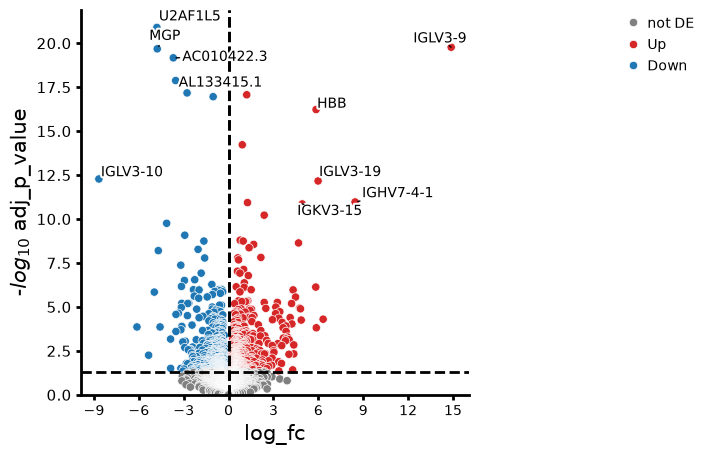

In [33]:
ds.plot_volcano(interaction_results_df, log2fc_thresh=0)

In [34]:
interaction_results_df

,variable,baseMean,log_fc,lfcSE,stat,p_value,adj_p_value,contrast
0,U2AF1L5,5.086603,-4.792563,0.456874,-10.489907,9.612318e-26,1.257099e-21,None
1,IGLV3-9,23.023332,14.877662,1.462214,10.174748,2.570644e-24,1.680944e-20,None
2,MGP,61.298000,-4.768772,0.471492,-10.114207,4.778712e-24,2.083200e-20,None
3,AC010422.3,5.249489,-3.694542,0.370580,-9.969618,2.070238e-23,6.768642e-20,None
4,AL133415.1,3.242984,-3.534810,0.366424,-9.646788,5.071963e-22,1.326623e-18,None
...,...,...,...,...,...,...,...,...
27080,AP001189.4,0.000000,NaN,NaN,NaN,NaN,NaN,None
27081,AC011595.1,0.000000,NaN,NaN,NaN,NaN,NaN,None
27082,TRDJ3,0.000000,NaN,NaN,NaN,NaN,NaN,None
27083,GOLGA6L1,0.000000,NaN,NaN,NaN,NaN,NaN,None


We can specify more contrasts, namely one that describes DE genes in responders across all treatments. This general trend can be visualized against our Anti-Pd-L1 treatment specifically in order to better see the difference in responders to the double treatment specifically v/s in general across all treatments.

In [35]:
general_response_contrast = ds.cond(Efficacy='PR') - ds.cond(Efficacy='SD')

interaction_results_df = ds.test_contrasts(
    {'Anti-PD-L1_specific': interaction_contrast, 'General': general_response_contrast}
)

Running Wald tests...
... done in 2.15 seconds.



Log2 fold change & Wald test p-value, contrast vector: [0. 0. 0. 1.]
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
AL627309.1   0.030299        0.441929  1.260079  0.350716  0.725802       NaN
AL669831.5   0.481510        0.000149  0.421881  0.000354  0.999718  0.999718
FAM87B       0.019790        0.464101  1.709468  0.271489  0.786015       NaN
LINC00115    1.663735        0.444530  0.249673  1.780447  0.075003  0.254116
NOC2L       13.022724        0.441258  0.117724  3.748223  0.000178  0.004734
...               ...             ...       ...       ...       ...       ...
AP001189.4   0.000000             NaN       NaN       NaN       NaN       NaN
AC011595.1   0.000000             NaN       NaN       NaN       NaN       NaN
TRDJ3        0.000000             NaN       NaN       NaN       NaN       NaN
GOLGA6L1     0.000000             NaN       NaN       NaN       NaN       NaN
AC008569.1   0.000000             NaN       NaN       NaN       NaN      

Running Wald tests...
... done in 2.13 seconds.



Log2 fold change & Wald test p-value, contrast vector: [ 0. -1.  0.  0.]
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
AL627309.1   0.030299       -0.185244  0.869869 -0.212956  0.831361       NaN
AL669831.5   0.481510       -0.375245  0.301549 -1.244392  0.213355  0.458320
FAM87B       0.019790        0.006963  1.182103  0.005891  0.995300       NaN
LINC00115    1.663735       -0.036692  0.181669 -0.201973  0.839938  0.932967
NOC2L       13.022724        0.149331  0.084369  1.769977  0.076731  0.251249
...               ...             ...       ...       ...       ...       ...
AP001189.4   0.000000             NaN       NaN       NaN       NaN       NaN
AC011595.1   0.000000             NaN       NaN       NaN       NaN       NaN
TRDJ3        0.000000             NaN       NaN       NaN       NaN       NaN
GOLGA6L1     0.000000             NaN       NaN       NaN       NaN       NaN
AC008569.1   0.000000             NaN       NaN       NaN       NaN  

In [36]:
interaction_results_df

,variable,baseMean,log_fc,lfcSE,stat,p_value,adj_p_value,contrast
0,U2AF1L5,5.086603,-4.792563,0.456874,-10.489907,9.612318e-26,1.257099e-21,Anti-PD-L1_specific
1,IGLV3-9,23.023332,14.877662,1.462214,10.174748,2.570644e-24,1.680944e-20,Anti-PD-L1_specific
2,MGP,61.298000,-4.768772,0.471492,-10.114207,4.778712e-24,2.083200e-20,Anti-PD-L1_specific
3,AC010422.3,5.249489,-3.694542,0.370580,-9.969618,2.070238e-23,6.768642e-20,Anti-PD-L1_specific
4,AL133415.1,3.242984,-3.534810,0.366424,-9.646788,5.071963e-22,1.326623e-18,Anti-PD-L1_specific
...,...,...,...,...,...,...,...,...
27080,AP001189.4,0.000000,NaN,NaN,NaN,NaN,NaN,General
27081,AC011595.1,0.000000,NaN,NaN,NaN,NaN,NaN,General
27082,TRDJ3,0.000000,NaN,NaN,NaN,NaN,NaN,General
27083,GOLGA6L1,0.000000,NaN,NaN,NaN,NaN,NaN,General


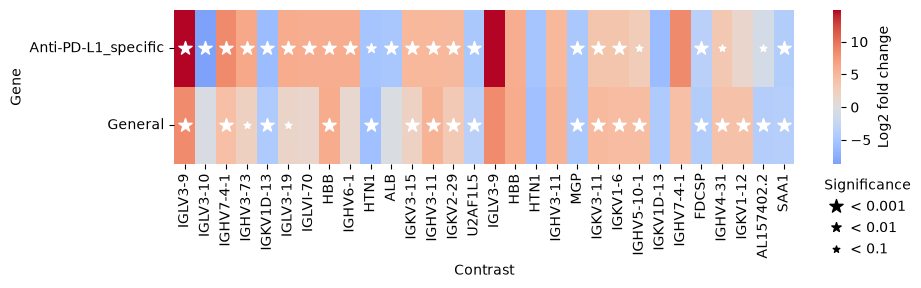

In [37]:
ds.plot_multicomparison_fc(interaction_results_df)

## Bonus section: gene set enrichment
The tutorial skips over enrichment analysis in order to keep focus on DE, but once you have a ranked gene table, you can still any form of enrichment analysis. You can turn sets of highly-ranked genes into sets of highly-associated pathways.

Let me try this for our drug-response analysis.

Are there any pathways or biological processes that are associated with responders specific to the Anti-PD-L1 + Chemo treatment? Let's use decoupler and see

In [47]:
interaction_results_df_2 = interaction_results_df[interaction_results_df['contrast'] == 'Anti-PD-L1_specific'].copy()
interaction_results_df_2.head(5)

,variable,baseMean,log_fc,lfcSE,stat,p_value,adj_p_value,contrast,abs_log_fc,significance
0,U2AF1L5,5.086603,-4.792563,0.456874,-10.489907,9.612318e-26,1.257099e-21,Anti-PD-L1_specific,4.792563,< 0.001
1,IGLV3-9,23.023332,14.877662,1.462214,10.174748,2.570644e-24,1.680944e-20,Anti-PD-L1_specific,14.877662,< 0.001
2,MGP,61.298000,-4.768772,0.471492,-10.114207,4.778712e-24,2.083200e-20,Anti-PD-L1_specific,4.768772,< 0.001
3,AC010422.3,5.249489,-3.694542,0.370580,-9.969618,2.070238e-23,6.768642e-20,Anti-PD-L1_specific,3.694542,< 0.001
4,AL133415.1,3.242984,-3.534810,0.366424,-9.646788,5.071963e-22,1.326623e-18,Anti-PD-L1_specific,3.534810,< 0.001


In [48]:
interaction_results_df_2 = interaction_results_df_2.set_index('variable', drop=True).copy()

In [49]:
interaction_results_df_2 = interaction_results_df_2[['stat']].dropna().T.rename(index={'stat': 'anti-pd-l1.specific'})

In [50]:
interaction_results_df_2

variable,U2AF1L5,IGLV3-9,MGP,AC010422.3,AL133415.1,MTRNR2L12,U2AF1,MT-ND6,HBB,RPS3A,...,WDR20,AC098679.1,AC009093.6,ITGAV,COL8A2,AL669831.5,CCDC153,AC099518.1,IGKJ4,PRTN3
anti-pd-l1.specific,-10.489907,10.174748,-10.114207,-9.969618,-9.646788,-9.460264,9.418602,-9.378061,9.186405,8.663539,...,0.000887,-0.000775,0.000699,-0.00066,0.000398,0.000354,0.000218,-0.000125,0.0,0.0


### Hallmark gene sets

In [51]:
hallmark = dc.op.hallmark(organism='human')

In [52]:
hm_scores, hm_padj = dc.mt.ulm(interaction_results_df_2, net=hallmark)

mask = (hm_padj.T < 0.05).iloc[:, 0]
hm_scores = hm_scores.loc[:, mask]

hm_scores

,ADIPOGENESIS,ALLOGRAFT_REJECTION,ANDROGEN_RESPONSE,ANGIOGENESIS,APICAL_JUNCTION,APOPTOSIS,BILE_ACID_METABOLISM,CHOLESTEROL_HOMEOSTASIS,COAGULATION,COMPLEMENT,...,NOTCH_SIGNALING,OXIDATIVE_PHOSPHORYLATION,P53_PATHWAY,PEROXISOME,PI3K_AKT_MTOR_SIGNALING,PROTEIN_SECRETION,TGF_BETA_SIGNALING,UNFOLDED_PROTEIN_RESPONSE,UV_RESPONSE_DN,XENOBIOTIC_METABOLISM
anti-pd-l1.specific,-4.612862,-3.126988,-3.207581,-4.107969,-4.534285,-5.379591,-2.121001,-4.342362,-7.302677,-8.905514,...,-3.043764,-4.092914,-3.556816,-2.181468,-3.46989,-3.381862,-2.418466,3.181897,-2.823353,-3.780752


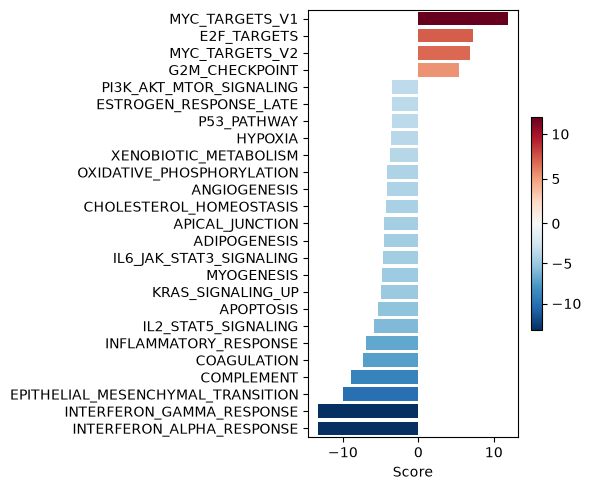

In [53]:
dc.pl.barplot(hm_scores, name="anti-pd-l1.specific", figsize=(6,5))

### CollecTRI network (transcription factors)

In [54]:
collectri = dc.op.collectri(organism='human')

In [55]:
tf_scores, tf_padj = dc.mt.ulm(interaction_results_df_2, net=collectri)

mask = (tf_padj.T < 0.05).iloc[:, 0]
tf_scores = tf_scores.loc[:, mask]

tf_scores

,AP1,AR,ATF1,ATF2,BCL11A,BCL3,CEBPA,CEBPB,CEBPD,CEBPG,...,TFAP2A,TGIF1,TP63,TP73,USF2,VDR,ZBTB7B,ZGLP1,ZNF362,ZNF384
anti-pd-l1.specific,-5.157181,-2.984359,-2.738835,-2.788871,-3.616388,-3.153893,-4.397589,-4.304545,-4.014146,-4.099063,...,-4.340149,2.995451,-4.591491,-4.877911,-2.999796,-4.077136,-3.640403,-2.953887,2.737923,-2.797834


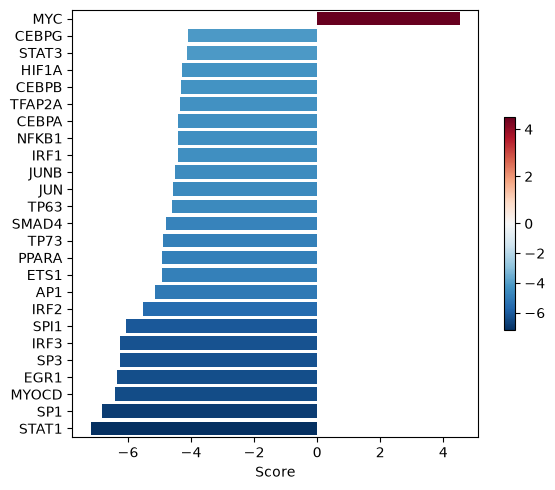

In [56]:
dc.pl.barplot(tf_scores, name="anti-pd-l1.specific", figsize=(6,5))

Flip analysis around to General treatment

In [57]:
interaction_results_df_2 = interaction_results_df[interaction_results_df['contrast'] == 'General'].copy()
interaction_results_df_2 = interaction_results_df_2.set_index('variable', drop=True).copy()
interaction_results_df_2 = interaction_results_df_2[['stat']].dropna().T.rename(index={'stat': 'general'})

hm_scores, hm_padj = dc.mt.ulm(interaction_results_df_2, net=hallmark)

mask = (hm_padj.T < 0.05).iloc[:, 0]
hm_scores = hm_scores.loc[:, mask]

hm_scores

,ADIPOGENESIS,ANDROGEN_RESPONSE,ANGIOGENESIS,APICAL_JUNCTION,APOPTOSIS,CHOLESTEROL_HOMEOSTASIS,COAGULATION,COMPLEMENT,DNA_REPAIR,E2F_TARGETS,...,MYOGENESIS,NOTCH_SIGNALING,P53_PATHWAY,PI3K_AKT_MTOR_SIGNALING,PROTEIN_SECRETION,TGF_BETA_SIGNALING,UNFOLDED_PROTEIN_RESPONSE,UV_RESPONSE_DN,WNT_BETA_CATENIN_SIGNALING,XENOBIOTIC_METABOLISM
general,-2.272529,-2.149,-3.564514,-3.553248,-4.799738,-3.854228,-4.128407,-5.336676,3.209433,11.980774,...,-5.413938,-2.307468,-4.015644,-3.234125,-2.197651,-2.9026,2.335356,-2.779406,-2.65999,-2.3336


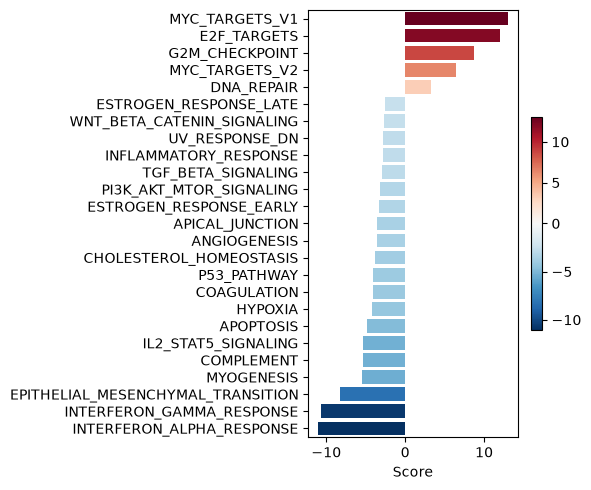

In [58]:
dc.pl.barplot(hm_scores, name="general", figsize=(6,5))

In [59]:
tf_scores, tf_padj = dc.mt.ulm(interaction_results_df_2, net=collectri)

mask = (tf_padj.T < 0.05).iloc[:, 0]
tf_scores = tf_scores.loc[:, mask]

tf_scores

,ARID4B,ATF1,BACH2,BCL11A,BHLHA15,BMAL1,E2F1,E2F2,E2F3,E2F4,...,SMARCC1,SP1,SP3,STAT1,TFAP2A,TFDP1,TGIF1,TP63,ZBTB7B,ZNF362
general,3.11664,-3.357152,-3.327753,-3.360279,-3.127294,-2.975537,4.719204,3.113862,3.268411,4.792853,...,3.355456,-4.297486,-4.812358,-4.51944,-3.252488,3.020382,3.606197,-3.790766,-3.858142,5.078687


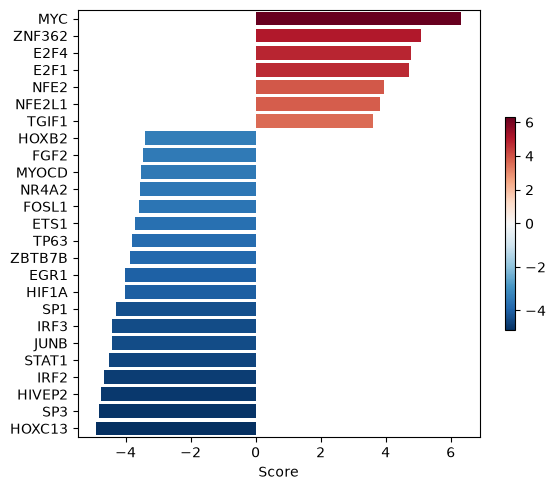

In [60]:
dc.pl.barplot(tf_scores, name="general", figsize=(6,5))

While both treatment types result in higher association with Myc targets, the general treatment results in higher E2F activity. The anti-PD-L1 treatment seems to not have increased E2F activity at all.

Here is the original publication for the Zhang dataset used here: https://www.sciencedirect.com/science/article/pii/S1535610821004992 